<a href="https://colab.research.google.com/github/zepha007/comparaison-mod-le-classique-vs-mod-le-robustesse/blob/main/regression_robuste_vs_ols.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# comparaison modèle classique vs modèle robustesse
**Nom et Prénom : ADJAHO Koku Eustache**


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [ ]:
#chargeons le data set
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")





In [ ]:
#ajoutons des outliers artificiels dans la cible
y_out = y.copy()
np.random.seed(42)
outlier_idx = np.random.choice(len(y), size=10, replace=False)
y_out[outlier_idx] += np.random.uniform(5, 10, size=10)


In [ ]:
#OLS et huber
ols = LinearRegression()
ols.fit(X, y_out)
y_pred_ols = ols.predict(X)

robust = HuberRegressor()
robust.fit(X, y_out)
y_pred_robust = robust.predict(X)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
#fonctions d'evaluation
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("R² :", r2_score(y_true, y_pred))
    print("RMSE :", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE :", mean_absolute_error(y_true, y_pred))



In [ ]:
#score
evaluate(y_out, y_pred_ols, "OLS")
evaluate(y_out, y_pred_robust, "Robust")




OLS
R² : 0.5943413025031368
RMSE : 0.7436474686642647
MAE : 0.5350739949075719

Robust
R² : 0.29693884007801463
RMSE : 0.9790012835326344
MAE : 0.5824403595034331


In [ ]:
#coefficient
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "OLS": ols.coef_,
    "Robust": robust.coef_
})
print("\nComparaison des coefficients :")
print(coef_df)




Comparaison des coefficients :
      Feature       OLS    Robust
0      MedInc  0.437648  0.490049
1    HouseAge  0.009440  0.016133
2    AveRooms -0.108228 -0.090523
3   AveBedrms  0.649075 -0.009333
4  Population -0.000004  0.000017
5    AveOccup -0.003795 -0.053452
6    Latitude -0.422476 -0.020442
7   Longitude -0.435627 -0.008368


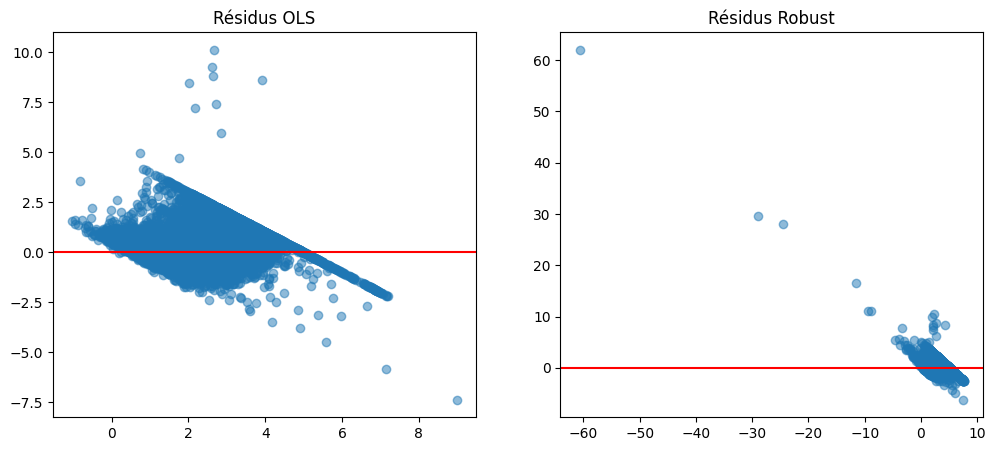

In [ ]:
#residus
res_ols = y_out - y_pred_ols
res_robust = y_out - y_pred_robust

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_pred_ols, res_ols, alpha=0.5)
plt.axhline(0, color='red')
plt.title("Résidus OLS")

plt.subplot(1,2,2)
plt.scatter(y_pred_robust, res_robust, alpha=0.5)
plt.axhline(0, color='red')
plt.title("Résidus Robust")
plt.show()




In [ ]:
# stabilisations après suppression des outliers
mask = y_out < y_out.quantile(0.99)

ols2 = LinearRegression().fit(X[mask], y_out[mask])
robust2 = HuberRegressor().fit(X[mask], y_out[mask])

coef_stability = pd.DataFrame({
    "Feature": X.columns,
    "OLS_before": ols.coef_,
    "OLS_after": ols2.coef_,
    "Robust_before": robust.coef_,
    "Robust_after": robust2.coef_
})

print("\nStabilité des coefficients après suppression des outliers :")
print(coef_stability)



Stabilité des coefficients après suppression des outliers :
      Feature  OLS_before  OLS_after  Robust_before  Robust_after
0      MedInc    0.437648   0.431892       0.490049      0.423714
1    HouseAge    0.009440   0.008180       0.016133      0.013181
2    AveRooms   -0.108228  -0.110380      -0.090523     -0.040619
3   AveBedrms    0.649075   0.612908      -0.009333     -0.025588
4  Population   -0.000004   0.000005       0.000017      0.000019
5    AveOccup   -0.003795  -0.003447      -0.053452     -0.071345
6    Latitude   -0.422476  -0.379460      -0.020442     -0.110972
7   Longitude   -0.435627  -0.395902      -0.008368     -0.035920


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


5-conclusion sur l'interet de la robustesse


 dans notre cas ici on remarque que l'ajout des outliers pertube le modèle OLS les scores RMSE et MAE sont mauvaises  tandis que le modèle HUBER resite face au outliers et produit de meilleurs score     donc nous retenous qu'il faut utliser les modèles de robustesses comme huber sur des données contenant des valeurs aberrantes